# 02 — Retention Cohorts

**Question:** are newer registration cohorts retaining better or worse than older ones, and
when subscribers don't renew, is revenue lost to voluntary cancellation or to silent lapse?
Those are different problems with different fixes — a voluntary cancel is a decision the
business had a chance to intervene on; a silent lapse often has no warning signal at all.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sys.path.append(str(Path.cwd().parent))
from src import cohorts, plotting

plotting.set_style()

interim = Path("../data/interim")
periods = pd.read_parquet(interim / "periods.parquet")
members_cohort = pd.read_parquet(interim / "members_cohort.parquet")

## Retention curve, all cohorts (heatmap)
Sequential color = magnitude. Read down a column to compare cohorts at the same tenure; read across a row to see one cohort's own decay curve.

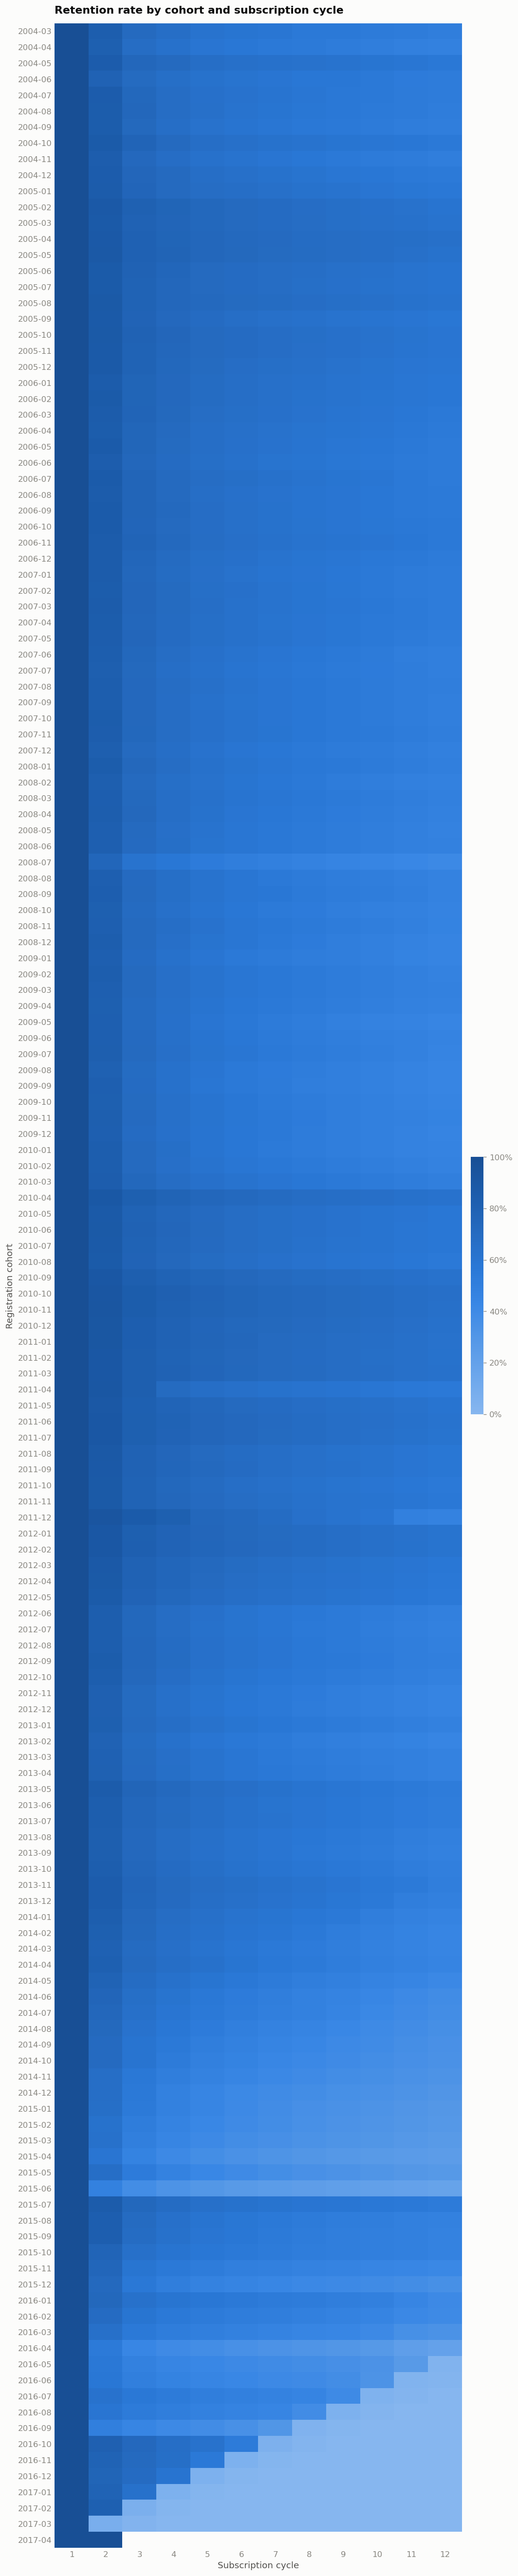

In [2]:
curve = cohorts.cohort_retention_curve(periods, members_cohort, max_cycle=12)
pivot = curve.pivot(index="cohort_month", columns="cycle", values="retention_rate").sort_index()

fig, ax = plotting.plot_cohort_heatmap(
    pivot, "Retention rate by cohort and subscription cycle",
    save_path="../figures/02_cohort_heatmap.png",
)

**How to read this:** a column that gets systematically lighter toward the bottom rows (the most recent cohorts) is the "newer cohorts churn faster" signal. A column that gets darker toward the bottom is the opposite. Compare within a column, not across the diagonal — cohorts at the bottom haven't had time to reach the columns on the right yet (see the reachable-horizon filter below).

## Reachable-horizon filter

Recent cohorts haven't had enough elapsed *calendar* time to reach cycle 6+ — comparing them
there would blame churn for what's actually just missing follow-up time. Eligibility is based on
calendar age (cohort age >= 6 x 30 days, the dominant plan length), not on whether any single
user in the cohort happened to reach that cycle: a handful of atypical fast-cycling users (short
plans, rapid repeat transactions) can technically reach cycle 6 long before the cohort as a whole
has had time to, which would bias that cohort's reported retention toward only its most unusual
members instead of a representative sample.

In [3]:
COMPARE_CYCLE = 6
observation_end = periods["transaction_date"].max()
eligible_cohorts = cohorts.cohort_calendar_eligible(members_cohort, COMPARE_CYCLE, observation_end)
all_cohorts = cohorts.cohort_sizes(members_cohort).index

print(f"{len(eligible_cohorts)} of {len(all_cohorts)} cohorts are at least {COMPARE_CYCLE * 30} days old as of {observation_end.date()} and eligible for comparison.")
print("Most recent 6 cohorts excluded as too young:", sorted(set(all_cohorts) - set(eligible_cohorts))[-6:])

152 of 158 cohorts are at least 180 days old as of 2017-03-31 and eligible for comparison.
Most recent 6 cohorts excluded as too young: [Timestamp('2016-11-01 00:00:00'), Timestamp('2016-12-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-02-01 00:00:00'), Timestamp('2017-03-01 00:00:00'), Timestamp('2017-04-01 00:00:00')]


## Restrict to a recent window for the trend comparison

Registration cohorts go back to 2004, and nearly all of them clear the cycle-6 bar — so
"earliest vs. most recent eligible" would otherwise compare ~2004-2008 registrants against
~2015-2016 ones. That's not a like-for-like trend read; the full 2004-2017 heatmap above is
useful long-run context, but the line chart and significance test below are restricted to a
rolling recent window instead, so "recent" means recent.

In [4]:
RECENT_WINDOW_MONTHS = 30
window_start = eligible_cohorts.max() - pd.DateOffset(months=RECENT_WINDOW_MONTHS)
recent_eligible = sorted(c for c in eligible_cohorts if c >= window_start)

print(f"{len(recent_eligible)} eligible cohorts in the last {RECENT_WINDOW_MONTHS} months: "
      f"{recent_eligible[0].strftime('%Y-%m')} to {recent_eligible[-1].strftime('%Y-%m')}")

31 eligible cohorts in the last 30 months: 2014-04 to 2016-10


## Line comparison — earliest vs. most recent cohorts in the recent window

Truncated to cycle 6, matching the eligibility check above — every cohort shown was verified
calendar-old-enough to reach cycle 6, but not necessarily cycle 12. Plotting further than that
per cohort would reintroduce the same survivorship artifact the eligibility filter exists to
prevent, just a few cycles later. The full 2004-2017 heatmap above remains the place to look at
longer decay curves for cohorts old enough to have them.

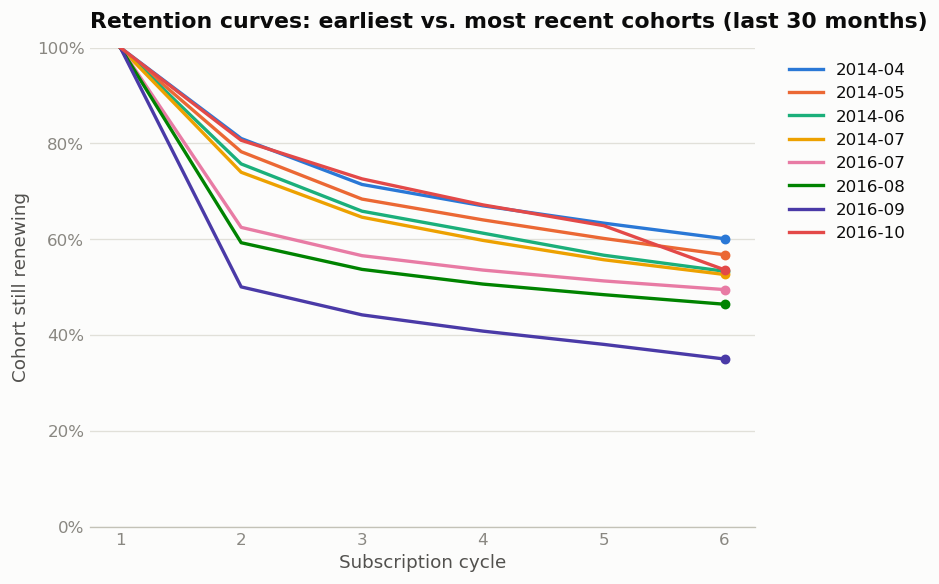

In [5]:
sample_cohorts = recent_eligible[:4] + recent_eligible[-4:]
line_pivot = pivot.loc[sample_cohorts, pivot.columns <= COMPARE_CYCLE].T  # cycle as index, cohort as columns

fig, ax = plotting.plot_cohort_retention_lines(
    line_pivot, f"Retention curves: earliest vs. most recent cohorts (last {RECENT_WINDOW_MONTHS} months)",
    save_path="../figures/02_cohort_lines.png",
)

## Is the early-vs-late difference statistically significant?
Two-proportion z-test on cycle-6 retention: earliest quarter of the recent window vs. most recent quarter.

In [6]:
n_early = max(len(recent_eligible) // 4, 1)
early_group, late_group = recent_eligible[:n_early], recent_eligible[-n_early:]

merged = periods.merge(members_cohort[["msno", "cohort_month"]], on="msno")
resolved = merged[merged["outcome"] != "censored"].copy()
resolved["cycle"] = resolved["period_seq"] + 1
at_cycle = resolved[resolved["cycle"] == COMPARE_CYCLE]

early_mask = at_cycle["cohort_month"].isin(early_group)
late_mask = at_cycle["cohort_month"].isin(late_group)

counts = [int(at_cycle.loc[early_mask, "renewed"].sum()), int(at_cycle.loc[late_mask, "renewed"].sum())]
nobs = [int(early_mask.sum()), int(late_mask.sum())]

z_stat, p_value = proportions_ztest(counts, nobs)
rate_early, rate_late = counts[0] / nobs[0], counts[1] / nobs[1]

print(f"Cycle {COMPARE_CYCLE} retention — earliest cohorts in window: {rate_early:.3f} (n={nobs[0]:,}), most recent cohorts in window: {rate_late:.3f} (n={nobs[1]:,})")
print(f"z = {z_stat:.2f}, p = {p_value:.4f}")

Cycle 6 retention — earliest cohorts in window: 0.943 (n=66,300), most recent cohorts in window: 0.977 (n=89,274)
z = -35.71, p = 0.0000


If `p_value` is below 0.05, the retention difference between the earliest and most recent cohorts in this recent window at cycle 6 is unlikely to be noise — report the direction and effect size, not just significance. If it's not significant, that's a legitimate finding too: cohort quality at this checkpoint has been roughly stable, and that should be reported as-is rather than reached past.

## Voluntary cancellation vs. silent lapse
Different problems, different fixes: voluntary cancel is a decision the business had a chance to intervene on; silent lapse often has no warning signal at all.

In [7]:
outcome_counts = cohorts.cohort_outcome_counts(periods, members_cohort)
outcome_counts["voluntary_share"] = outcome_counts["voluntary_cancel"] / (
    outcome_counts["voluntary_cancel"] + outcome_counts["lapsed_no_renewal"]
)
print(outcome_counts.tail(12))

outcome       lapsed_no_renewal  renewed  voluntary_cancel  voluntary_share
cohort_month                                                               
2016-05-01                21418   145577              2615         0.108809
2016-06-01                20505   151741              2215         0.097491
2016-07-01                17996   164689              2210         0.109373
2016-08-01                17893   132984              1776         0.090294
2016-09-01                17106    76864              1128         0.061862
2016-10-01                 3806    70559               819         0.177081
2016-11-01                 4041    59371               597         0.128719
2016-12-01                 3672    49271               520         0.124046
2017-01-01                 2238    31367               296         0.116811
2017-02-01                  128    19002                46         0.264368
2017-03-01                    0     1767                 4         1.000000
2017-04-01  

In [8]:
table = outcome_counts.loc[eligible_cohorts, ["voluntary_cancel", "lapsed_no_renewal"]]
chi2, p, dof, _ = stats.chi2_contingency(table)
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p:.4g}")
print("Tests whether the MIX of voluntary-cancel vs. silent-lapse shifts across cohorts (not whether the total churn rate does).")

chi2 = 33243.6, dof = 151, p = 0
Tests whether the MIX of voluntary-cancel vs. silent-lapse shifts across cohorts (not whether the total churn rate does).


## Revenue retained vs. lost, by cohort

Across these cohorts: NT$301,497,234 retained vs NT$23,461,324 lost (7.2% of resolved revenue).
Of the lost revenue: 16.7% voluntary cancellation, 83.3% silent lapse.


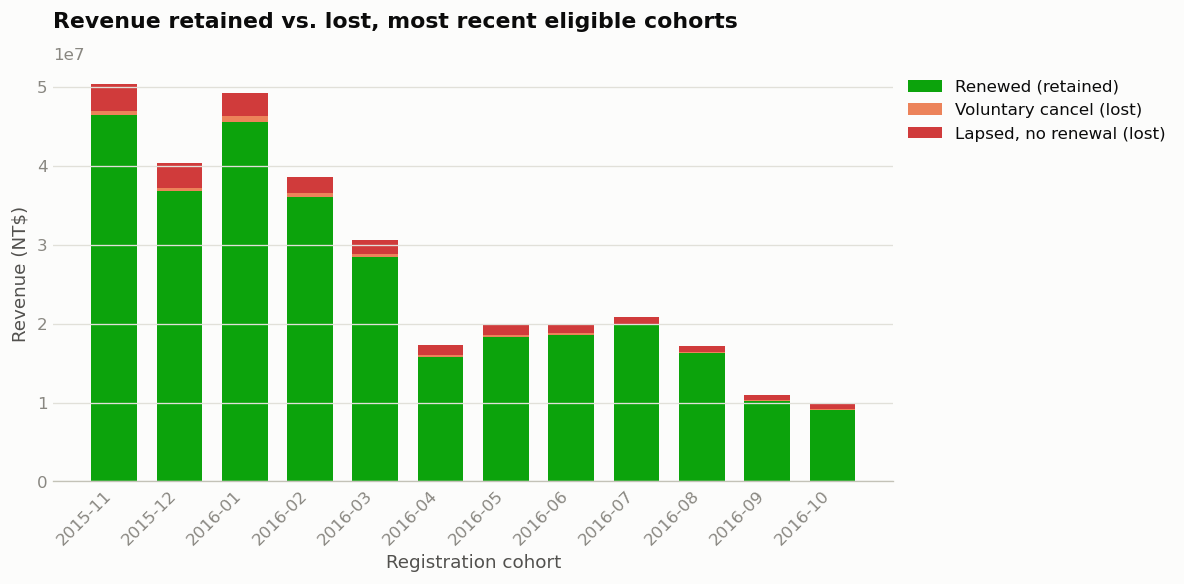

In [9]:
revenue = cohorts.cohort_revenue_summary(periods, members_cohort)
recent_cohorts = eligible_cohorts[-12:] if len(eligible_cohorts) >= 12 else eligible_cohorts
revenue_recent = revenue.loc[recent_cohorts]

fig, ax = plotting.plot_revenue_outcome_bars(
    revenue_recent, "Revenue retained vs. lost, most recent eligible cohorts",
    save_path="../figures/02_revenue_outcome.png",
)

lost = revenue_recent[["voluntary_cancel", "lapsed_no_renewal"]].sum(axis=1)
retained = revenue_recent["renewed"]
total = retained.sum() + lost.sum()
print(f"Across these cohorts: NT${retained.sum():,.0f} retained vs NT${lost.sum():,.0f} lost ({lost.sum()/total:.1%} of resolved revenue).")
print(f"Of the lost revenue: {revenue_recent['voluntary_cancel'].sum()/lost.sum():.1%} voluntary cancellation, {revenue_recent['lapsed_no_renewal'].sum()/lost.sum():.1%} silent lapse.")

## Section summary

Fill in against the actual run output above:
- Cohort trend direction at cycle 6, and whether the z-test found it significant.
- Whether lost revenue skews toward voluntary cancellation (addressable with retention offers /
  win-back campaigns) or silent lapse (needs a different lever — renewal reminders, grace
  periods, auto-renew defaults).
- This feeds directly into the prioritization in the README's recommendation memo.